In [54]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# Veriyi doğrudan çek
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# X ve y ayrımı
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

In [55]:
df
df.describe()
#has no empty cells.
#needs feature scaling.
#MedInc (Median Income): O bloktaki hane halklarının medyan (ortalama) geliri (10.000$birimindedir, örn: 3.5 = 35.000$).
#HouseAge (Median House Age): O bloktaki evlerin medyan yaşı.
#AveRooms (Average Rooms): Ev başına düşen ortalama oda sayısı.
#AveBedrms (Average Bedrooms): Ev başına düşen ortalama yatak odası sayısı.
#opulation (Population): O blokta yaşayan toplam nüfus.
#AveOccup (Average Occupancy): Ev başına düşen ortalama hane üyesi (sakin) sayısı.
#Latitude (Latitude): Bloğun enlem koordinatı.
#Longitude (Longitude): Bloğun boylam koordinatı.
#MedHouseVal (Median House Value) — Target (y): O bloktaki evlerin medyan değeri (100.000$birimindedir, örn: 2.5 = 250.000$). Tahmin etmeye çalışacağın hedef değişken budur.

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [56]:
#DATA PREPROCESSING
#AYKIRI DEGER VAR MI YOK MU ONU KONTROL EDELIM.
#1) describe ile %75 ile max degerleri arasindaki farkin fazlaligina gore outlier oldugunu anlayabiliriz.
#df.describe() #INCELEME (max/%75):MedInc(15/4.7),AveRooms(141/6),AveBedrms(34/1),Population(35,6/1.7),AveOccup(1243/3.2)
#gorulecegi uzere AveRooms,AveBedrms,Population,AveOccup degerlerinin %75'i ile max'i arasinda ucurum var. Bu kolonlarda outlier orani fazla. Temizlemek icin filteleyecegiz.

df_clean = df[df["MedHouseVal"] < 5.0].copy()
q_high = df_clean[["AveRooms", "AveBedrms", "AveOccup", "Population"]].quantile(0.995)
df_clean = df_clean[
    (df_clean["AveRooms"] < q_high["AveRooms"]) &
    (df_clean["AveBedrms"] < q_high["AveBedrms"]) &
    (df_clean["AveOccup"] < q_high["AveOccup"]) &
    (df_clean["Population"] < q_high["Population"])
]

from sklearn.model_selection import train_test_split
#print(df.columns)
# her seyden once hedef degisken ve bagimsiz degiskenler belirlenir.
HEDEF = "MedHouseVal"
BAGIMSIZ = [ # bagimsiz degisken kolonlarinin isimleri listesi
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude",
]

#hedef ve bagimsiz degiskenler belirlendikten X,y olarak atanarak ayri dataframeler olusturulur.
X = df_clean[BAGIMSIZ] # X = sadece bagimsiz kolonlarinin olusturdugu dataframe tablosu
y = df_clean[HEDEF] # y = sadece hedef kolonunun olusturdugu dataframe tablosu
#y.shape #(20640,)
#X.shape #(20640, 8)

#TRAIN TEST SPLIT icin scikitlearn kutuphanesi kullanilir. (train_test_split(X,y,random_state = 42))
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)
#print(f"X_train= {X_train},shape = {X_train.shape}") #shape= (15221, 8)
#print(f"y_train= {y_train},shape = {y_train.shape}") #shape= (15221,)

#ayirdiktan sonra verileri olceklememeiz gerekecek.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#lineer regresyonda sadece bagimli degiskenler yani X train ve test verilerini olceklendiririz. Cunku y'yi yani ev fiyatini olceklemek modelin tahminlerini anlamsiz sayilar yapar.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("scaling done.")

scaling done.


In [57]:
#Data Preprocessing bitti. Sirada olceklenmis train verileri ile lineer regresyon modeli kurmak ve egitmek kaldi.
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train) #X ve y verileri ile denetimli ogrenme yapar. Fit X ve y arasindaki istatistigi bulmak ve kaydetmek icindir.
#egitim asamasi bir satirdan ibarettir.
print("egitim tamamlandi")
print("simdi tahminlerimizi bulacagiz:")
y_pred = lr.predict(X_test_scaled) #X test verisi ile predict metodunu bir araya getirerek y verisi olmayan X_test_scaled'in y'lerini tahmin edecek

# NumPy dizisini Pandas Series/DataFrame'e çevirip kaydediyoruz
pd.Series(y_pred, name="y_pred").to_csv("/content/sample_data/y_pred_linreg.csv", index=False)
print("tahmin verisi sample_data klasorune kaydedildi")

egitim tamamlandi
simdi tahminlerimizi bulacagiz:
tahmin verisi sample_data klasorune kaydedildi


In [58]:
#Sirada gercek-tahmin verilerini degerlendirmek kaldi:
#hata fonksiyonlarini kullanarak basit bir sekilde residual'i sergileyelim:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Ortlama Kaer Hata   : {mse:.4f}")
print(f"Ortalama Mutlak Hata (MAE)     : {mae:.4f}")
print(f"Kök Ortalama Kare Hata (RMSE)  : {rmse:.4f}")
print(f"R-Kare (R2 Score)             : {r2:.4f}")

Ortlama Kaer Hata   : 0.3507
Ortalama Mutlak Hata (MAE)     : 0.4406
Kök Ortalama Kare Hata (RMSE)  : 0.5922
R-Kare (R2 Score)             : 0.6348


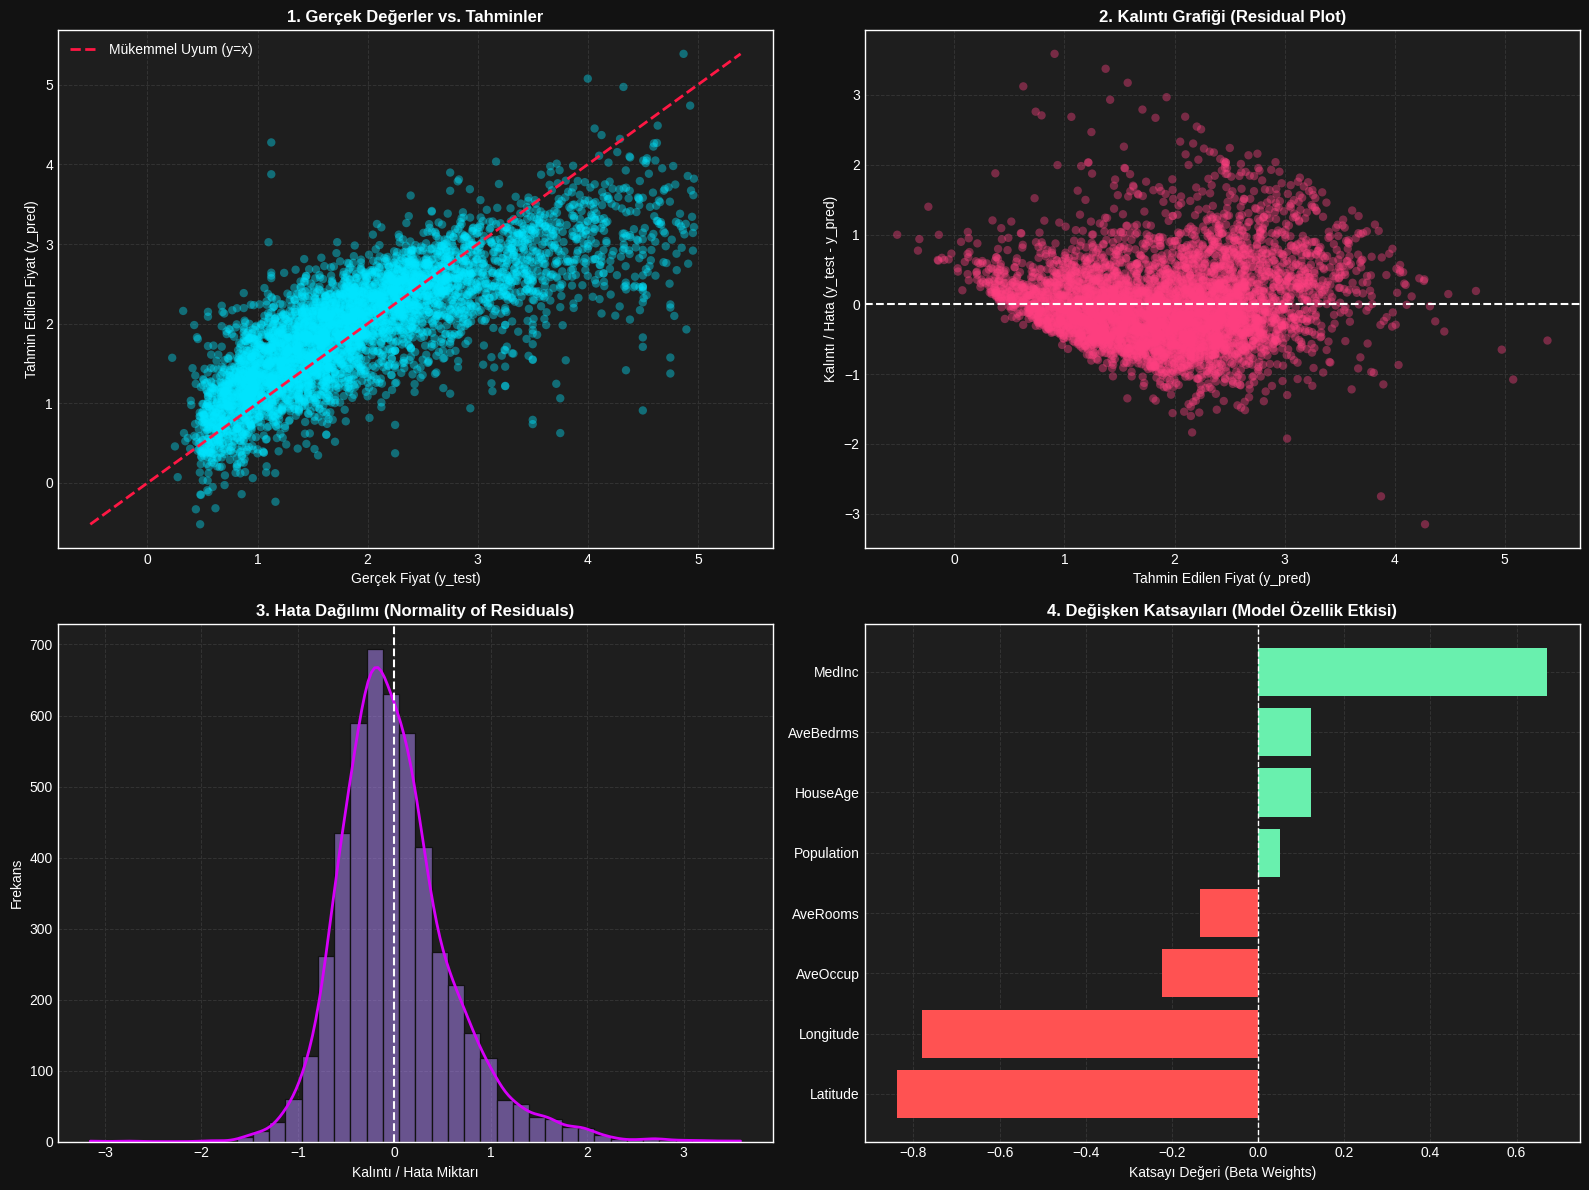

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# Karanlık Mod Tema Ayarları
# -------------------------------------------------------------------------
plt.style.use("dark_background")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#121212') # Figür arka planı (Koyu Gri)

for ax in axes.flat:
    ax.set_facecolor('#1e1e1e')   # Grafik iç alan arka planı
    ax.grid(color='#333333', linestyle='--', linewidth=0.7) # Grid çizgileri

# Kalıntıları (Residuals) Hesaplama
kalintilar = y_test - y_pred

# -------------------------------------------------------------------------
# 1. Gerçek Değerler vs. Tahmin Edilen Değerler (Actual vs. Predicted)
# -------------------------------------------------------------------------
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, ax=axes[0, 0], color="#00e5ff", edgecolor="none")

# Mükemmel tahmin doğrusu (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], color="#ff1744", linestyle="--", lw=2, label="Mükemmel Uyum (y=x)")

axes[0, 0].set_title("1. Gerçek Değerler vs. Tahminler", fontsize=12, fontweight="bold", color="white")
axes[0, 0].set_xlabel("Gerçek Fiyat (y_test)", color="white")
axes[0, 0].set_ylabel("Tahmin Edilen Fiyat (y_pred)", color="white")
axes[0, 0].legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white')

# -------------------------------------------------------------------------
# 2. Kalıntı Grafiği (Residual Plot - Homoscedasticity Kontrolü)
# -------------------------------------------------------------------------
sns.scatterplot(x=y_pred, y=kalintilar, alpha=0.4, ax=axes[0, 1], color="#ff4081", edgecolor="none")
axes[0, 1].axhline(y=0, color="white", linestyle="--", lw=1.5)

axes[0, 1].set_title("2. Kalıntı Grafiği (Residual Plot)", fontsize=12, fontweight="bold", color="white")
axes[0, 1].set_xlabel("Tahmin Edilen Fiyat (y_pred)", color="white")
axes[0, 1].set_ylabel("Kalıntı / Hata (y_test - y_pred)", color="white")

# -------------------------------------------------------------------------
# 3. Kalıntıların Dağılımı (Normallik Varsayımı Kontrolü)
# -------------------------------------------------------------------------
sns.histplot(kalintilar, kde=True, ax=axes[1, 0], color="#b388ff", bins=40, edgecolor="#121212")
axes[1, 0].axvline(x=0, color="white", linestyle="--", lw=1.5)

# KDE çizgi rengini belirginleştirme
axes[1, 0].lines[0].set_color('#d500f9')
axes[1, 0].lines[0].set_linewidth(2)

axes[1, 0].set_title("3. Hata Dağılımı (Normality of Residuals)", fontsize=12, fontweight="bold", color="white")
axes[1, 0].set_xlabel("Kalıntı / Hata Miktarı", color="white")
axes[1, 0].set_ylabel("Frekans", color="white")

# -------------------------------------------------------------------------
# 4. Model Katsayıları / Özellik Önem Dereceleri (Feature Importance)
# -------------------------------------------------------------------------
coef_df = pd.DataFrame({
    "Feature": X_train.columns if hasattr(X_train, 'columns') else BAGIMSIZ,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=True)

# Neon Kırmızı / Neon Yeşil renkler
colors = ["#ff5252" if c < 0 else "#69f0ae" for c in coef_df["Coefficient"]]
axes[1, 1].barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="none")
axes[1, 1].axvline(x=0, color="white", linestyle="--", lw=1)

axes[1, 1].set_title("4. Değişken Katsayıları (Model Özellik Etkisi)", fontsize=12, fontweight="bold", color="white")
axes[1, 1].set_xlabel("Katsayı Değeri (Beta Weights)", color="white")

plt.tight_layout()
plt.show()